# RMS Mast607A — myogenic ordering + ATAC-precedes-RNA analysis

We (1) validate the Mesoderm/Myoblast/Myocyte labels with canonical markers, (2) build an RNA-velocity
ordering (scVelo dynamical latent time) and show the ATAC-vs-RNA marker trends along it, then (3) repeat the
ATAC-vs-RNA analysis along diffusion pseudotime (DPT), which cleanly recapitulates the trajectory, and
confirm with an orthogonal CytoTRACE ordering. Runs in the `velocity` conda env.

In [238]:
import os
import anndata
import scvelo as scv
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, rankdata

scv.settings.verbosity = 2

In [239]:
BASE   = "/path/to/multiomeBench/RMS/benchmark/atac_precede_rna"
LOOM   = os.path.join(BASE, "velocyto", "Mast607A.loom")
PT_CSV = os.path.join(BASE, "pseudotime_table.csv")      # barcode_base, cell_type, dpt_pseudotime, <gene>_rna
AT_CSV = os.path.join(BASE, "region_atac_percell.csv")   # barcode_base, <gene>_atac
H5     = "/path/to/data/RMS/Mast607A_TB19_22652/Mast607A_TB19_22652/outs/filtered_feature_bc_matrix.h5"
scv.settings.figdir = BASE + "/"
GENES       = ["MYOD1", "MYOG", "MYH3", "MEF2C"]          # MRFs (MYOD1/MYOG) + terminal MYH3 + myocyte TF MEF2C
STATE_ORDER = ["Mesoderm", "Myoblast", "Myocyte"]         # early -> late
N_BINS      = 15
CONF_MIN    = 0.7

## 1. Load loom + align barcodes (label-free)
`Mast607A:<16bp>x -> <16bp>-1`; keep the annotated cells; record total gene count (CytoTRACE anchor).

In [240]:
adata = anndata.read_loom(LOOM)
adata.var_names_make_unique()
adata.obs["barcode_base"] = [b.split(":")[-1].replace("x", "") + "-1" for b in adata.obs_names]
adata.obs_names = adata.obs["barcode_base"].values
adata.obs_names_make_unique()

pt = pd.read_csv(PT_CSV).set_index("barcode_base")
shared = [b for b in adata.obs_names if b in pt.index]
print(f"overlap loom <-> annotated cells: {len(shared)} / {adata.n_obs}")
adata = adata[shared].copy()
adata.obs["cell_type"]      = pd.Categorical(pt.loc[shared, "cell_type"].values, categories=STATE_ORDER, ordered=True)
adata.obs["dpt_pseudotime"] = pt.loc[shared, "dpt_pseudotime"].values
adata.obs["n_genes_all"]    = np.asarray((adata.layers["spliced"] > 0).sum(1)).ravel()

overlap loom <-> annotated cells: 8055 / 8291


## 1b. Validate the cell-type labels with canonical myogenic markers
Expect a diagonal — Mesoderm high for progenitor genes, Myoblast for MYF5/MYOD1 + proliferation, Myocyte for
MYOG + structural genes.

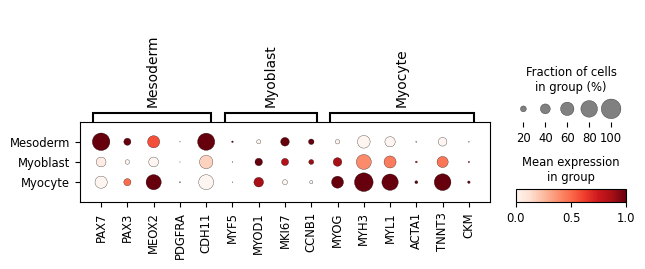

Mesoderm {'PAX7': 1.59, 'PAX3': 0.26, 'MEOX2': 0.82, 'PDGFRA': 0.01, 'CDH11': 1.57}
Myoblast {'MYF5': 0.01, 'MYOD1': 0.29, 'MKI67': 0.33, 'CCNB1': 0.16}
Myocyte {'MYOG': 0.4, 'MYH3': 2.39, 'MYL1': 1.29, 'ACTA1': 0.05, 'TNNT3': 1.09, 'CKM': 0.04}


In [241]:
MARKERS = {
    "Mesoderm": ["PAX7", "PAX3", "MEOX2", "PDGFRA", "CDH11"],
    "Myoblast": ["MYF5", "MYOD1", "MKI67", "CCNB1"],
    "Myocyte":  ["MYOG", "MYH3", "MYL1", "ACTA1", "TNNT3", "CKM"],
}
gex = sc.read_10x_h5(H5); gex.var_names_make_unique()
gex = gex[[b for b in gex.obs_names if b in set(adata.obs_names)]].copy()
gex.obs["cell_type"] = pd.Categorical(adata.obs.loc[gex.obs_names, "cell_type"].values,
                                      categories=STATE_ORDER, ordered=True)
sc.pp.normalize_total(gex, target_sum=1e4)                          # linear library-norm (per 10k UMIs)
# extract the ATAC-analysis marker RNA HERE (linear, matches the ATAC scale) -> Sections 6/7 use this, so they
# do NOT depend on RNA from pseudotime_table.csv (that file is now used only for DPT + labels).
gg = [g for g in GENES if g in gex.var_names]
rna_df = pd.DataFrame(np.asarray(gex[:, gg].X.todense()), index=gex.obs_names.values,
                      columns=[f"{g}_rna" for g in gg])
sc.pp.log1p(gex)                                                    # log only for the marker dotplot below
mk = {k: [g for g in v if g in gex.var_names] for k, v in MARKERS.items()}
sc.pl.dotplot(gex, mk, groupby="cell_type", categories_order=STATE_ORDER,
              standard_scale="var", save="_marker_check.png")
for st, gs in mk.items():
    print(st, {g: round(float(np.asarray(gex[gex.obs['cell_type'] == st, g].X.mean())), 2) for g in gs})

## 2. scVelo dynamical model
normalize -> PCA/neighbors -> moments -> `recover_dynamics` -> dynamical velocity -> latent time.

In [242]:
scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=30)
scv.pp.moments(adata, n_pcs=None, n_neighbors=None)

Filtered out 22052 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.


/path/to/home/.conda/envs/velocity/lib/python3.12/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


computing moments based on connectivities
    finished (0:00:01)


In [243]:
H5AD = os.path.join(BASE, "Mast607A_scvelo.h5ad")
if os.path.exists(H5AD):
    adata = sc.read_h5ad(H5AD)                 # reuse a previous run -> skip the ~10-min recover_dynamics
    # re-attach labels/DPT/n_genes from the current pseudotime table in case the cache predates them
    adata.obs["cell_type"]      = pd.Categorical(pt.loc[adata.obs_names, "cell_type"].values, categories=STATE_ORDER, ordered=True)
    adata.obs["dpt_pseudotime"] = pt.loc[adata.obs_names, "dpt_pseudotime"].values
    if "n_genes_all" not in adata.obs:
        adata.obs["n_genes_all"] = np.asarray((adata.layers.get("spliced", adata.X) > 0).sum(1)).ravel()
    print("loaded cached", H5AD, "|", adata.shape)
else:
    scv.tl.recover_dynamics(adata, n_jobs=8)   # slow (~5-10 min), first time only
    scv.tl.velocity(adata, mode="dynamical")
    scv.tl.velocity_graph(adata)
    scv.tl.latent_time(adata)
    adata.write_h5ad(H5AD)
    print("saved", H5AD)

loaded cached /path/to/multiomeBench/RMS/benchmark/atac_precede_rna/Mast607A_scvelo.h5ad | (8055, 2000)


## 3. Velocity QC -> exclude low-confidence cells

In [244]:
scv.tl.velocity_confidence(adata)
qs = adata.obs["velocity_confidence"].quantile([0.1, 0.25, 0.5, 0.75]).round(2)
print("velocity_confidence  mean=%.2f | q10=%.2f q25=%.2f median=%.2f q75=%.2f"
      % (adata.obs["velocity_confidence"].mean(), qs[0.1], qs[0.25], qs[0.5], qs[0.75]))
keep = adata.obs["velocity_confidence"] >= CONF_MIN
print(f"keeping {int(keep.sum())}/{adata.n_obs} cells (velocity_confidence >= {CONF_MIN})")
adata_hi = adata[keep].copy()

velocity_confidence  mean=0.78 | q10=0.52 q25=0.72 median=0.84 q75=0.90
keeping 6154/8055 cells (velocity_confidence >= 0.7)


## 4. Velocity ordering: dynamical latent time
The standard scVelo ordering, oriented so Mesoderm precedes Myocyte (the known direction).

In [245]:
def per_state(ad, col): return ad.obs.groupby("cell_type")[col].mean().reindex(STATE_ORDER)
v = adata_hi.obs["latent_time"].astype(float)
if per_state(adata_hi, "latent_time")["Mesoderm"] > per_state(adata_hi, "latent_time")["Myocyte"]:
    v = v.max() - v                                       # orient early -> late
adata_hi.obs["latent_time_o"] = v.values
m = per_state(adata_hi, "latent_time_o")
rho = spearmanr(adata_hi.obs["latent_time_o"], adata_hi.obs["dpt_pseudotime"]).correlation
print("latent_time per state:", m.round(3).to_dict())
print("monotonic Mesoderm<Myoblast<Myocyte:", bool(m["Mesoderm"] < m["Myoblast"] < m["Myocyte"]),
      "| Spearman vs DPT:", round(rho, 2))

latent_time per state: {'Mesoderm': 0.38, 'Myoblast': 0.321, 'Myocyte': 0.602}
monotonic Mesoderm<Myoblast<Myocyte: False | Spearman vs DPT: 0.16


## 5. Velocity stream + latent time by state

computing velocity graph (using 1/80 cores)


/path/to/home/.conda/envs/velocity/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=3174952) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:00:09)


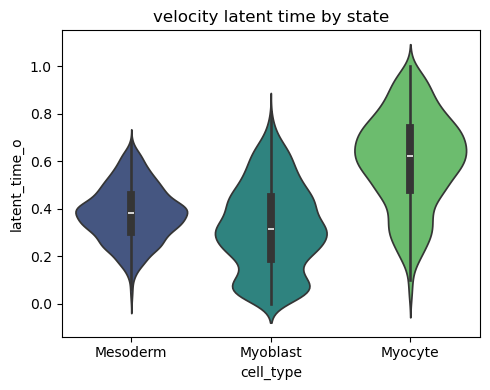

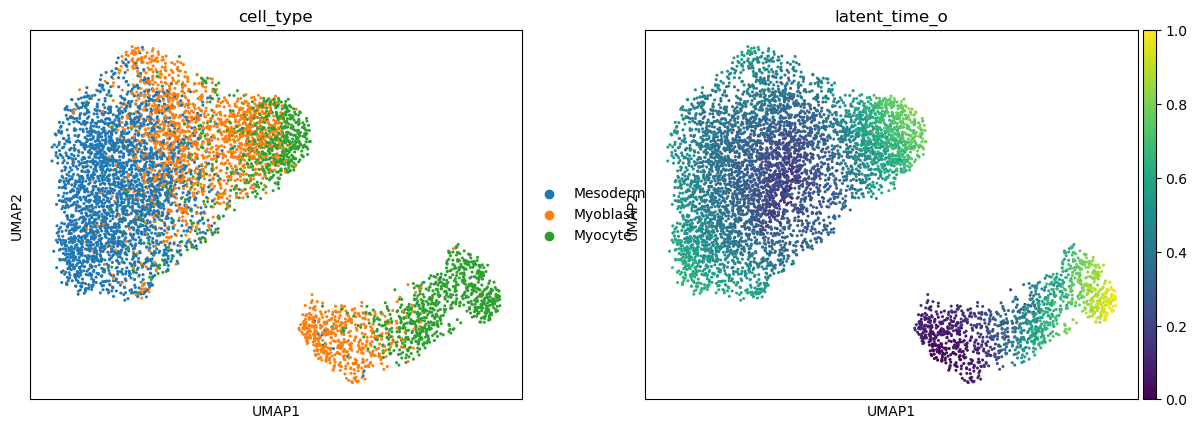

computing velocity embedding
    finished (0:00:00)


/path/to/home/.conda/envs/velocity/lib/python3.12/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/path/to/home/.conda/envs/velocity/lib/python3.12/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/path/to/home/.conda/envs/velocity/lib/python3.12/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/path/to/home/.conda/envs/velocity/lib/python3.12/site-pac

saving figure to file /path/to/multiomeBench/RMS/benchmark/atac_precede_rna/scvelo_scvelo_stream.png


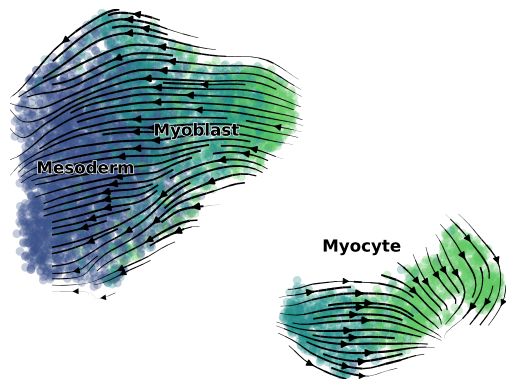

In [246]:
# recompute the neighbour + velocity graph ON the high-confidence subset: the copied full-data graph has
# stale indices (-> IndexError in the stream) and gives a distorted, split UMAP.
sc.pp.neighbors(adata_hi, n_pcs=30, n_neighbors=30)
scv.tl.velocity_graph(adata_hi)
sc.tl.umap(adata_hi)

plt.figure(figsize=(5, 4))
sns.violinplot(data=adata_hi.obs, x="cell_type", y="latent_time_o", order=STATE_ORDER, palette="viridis")
plt.title("velocity latent time by state"); plt.tight_layout()
plt.savefig(os.path.join(BASE, "scvelo_latenttime_by_state.png"), dpi=200); plt.show()
sc.pl.umap(adata_hi, color=["cell_type", "latent_time_o"], save="_scvelo_latenttime.png")
scv.pl.velocity_embedding_stream(adata_hi, basis="umap", color="cell_type",
                                 palette=sns.color_palette("viridis", 3), title="",
                                 legend_fontsize=12, save="scvelo_stream.png")

## 6. Does ATAC precede RNA? — per-marker accessibility vs expression along velocity latent time
For each marker, order cells by the scVelo latent time, bin, and overlay normalized ATAC accessibility vs
RNA expression. An earlier ATAC half-max bin than RNA = chromatin opens before transcription. (Latent time
only weakly orders the states here, so this is the velocity-ordered view; the DPT version follows.)

[velocity latent time] cells=6154 bins=15 (~410 cells/bin)
state mean bin / mean pseudotime: {'Mesoderm': (6.4, 0.38), 'Myoblast': (5.1, 0.321), 'Myocyte': (10.8, 0.602)}
gene   xcorr_lag(cells)  xcorr_lag(bins)   (+ = ATAC precedes)
  MYOD1         -1500            -3.66
  MYOG          -1424            -3.47
  MYH3           -853            -2.08
  MEF2C          -527            -1.28


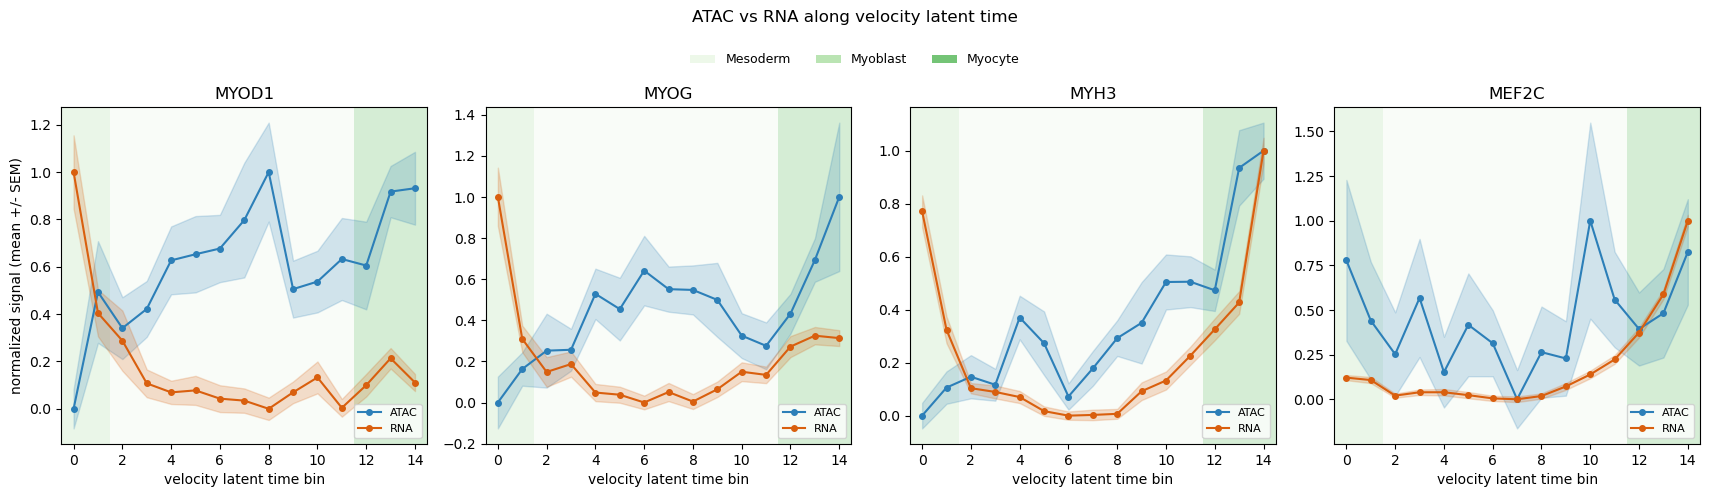

In [247]:
at = pd.read_csv(AT_CSV)
if at.columns[0].strip('"') != "barcode_base": at = at.rename(columns={at.columns[0]: "barcode_base"})
at = at.set_index("barcode_base")
rna_cols = [f"{g}_rna" for g in GENES]; atac_cols = [f"{g}_atac" for g in GENES]

def norm01(v): v = np.asarray(v, float); return (v - np.nanmin(v)) / (np.nanmax(v) - np.nanmin(v) + 1e-9)

# Cross-correlation lag along the pseudotime-SORTED cells (per-cell resolution, whole-curve alignment).
# Smooth each per-cell signal (rolling mean, w cells) -> slide ATAC vs RNA -> the shift L that maximizes the
# correlation. np.roll(a, L) delays ATAC by L cells, so a positive L means ATAC LED RNA => ATAC precedes.
def xcorr_lag(d, gene, w=400, max_lag=1500):
    s = d.sort_values("time")
    r = pd.Series(norm01(s[f"{gene}_rna"].values)).rolling(w, center=True, min_periods=1).mean().values
    a = pd.Series(norm01(s[f"{gene}_atac"].values)).rolling(w, center=True, min_periods=1).mean().values
    r, a, lags = r - r.mean(), a - a.mean(), range(-max_lag, max_lag + 1)
    cc = [np.corrcoef(np.roll(a, L)[abs(L):len(a)-abs(L) or None], r[abs(L):len(r)-abs(L) or None])[0, 1] for L in lags]
    return list(lags)[int(np.nanargmax(cc))]

from matplotlib.patches import Patch
STATE_COLOR = {"Mesoderm": "#edf8e9", "Myoblast": "#bae4b3", "Myocyte": "#74c476"}   # pale greens, early -> late

def atac_precede_grid(time, label, fname):               # time = per-cell pseudotime Series (index=barcode_base)
    d = pd.DataFrame({"time": time}).join(rna_df).join(at[atac_cols]).join(pt["cell_type"]).dropna()
    cpb = len(d) / N_BINS                                 # cells per bin -> convert the cross-corr lag to bins
    d["bin"] = pd.qcut(d["time"], q=N_BINS, labels=False, duplicates="drop")
    bins = np.sort(d["bin"].unique())
    dom = d.groupby("bin")["cell_type"].agg(lambda s: s.value_counts().idxmax())      # state owning each bin
    stt = d.groupby("cell_type", observed=True).agg(mean_bin=("bin", "mean"), mean_time=("time", "mean")).reindex(STATE_ORDER)
    fig, axes = plt.subplots(1, len(GENES), figsize=(4.3 * len(GENES), 4.6))
    print(f"[{label}] cells={len(d)} bins={len(bins)} (~{cpb:.0f} cells/bin)")
    print("state mean bin / mean pseudotime:",
          {s: (round(float(stt.loc[s, 'mean_bin']), 1), round(float(stt.loc[s, 'mean_time']), 3)) for s in STATE_ORDER})
    print("gene   xcorr_lag(cells)  xcorr_lag(bins)   (+ = ATAC precedes)")
    for ax, gene in zip(axes, GENES):
        for b in bins:                                    # shade each bin by the state that dominates it
            ax.axvspan(b - 0.5, b + 0.5, color=STATE_COLOR.get(dom.get(b, ""), "white"), alpha=0.3, lw=0, zorder=0)
        for sig, col, color in [("ATAC", f"{gene}_atac", "#2c7fb8"), ("RNA", f"{gene}_rna", "#d95f0e")]:
            gb = d.groupby("bin")[col]                    # per-bin mean +/- SEM = the VISUALIZATION only
            mean = gb.mean().reindex(bins).values
            sem  = (gb.std() / np.sqrt(gb.count())).reindex(bins).values
            lo, hi = np.nanmin(mean), np.nanmax(mean); rng = hi - lo + 1e-9
            mn, se = (mean - lo) / rng, sem / rng
            ax.plot(bins, mn, "-o", ms=4, color=color, label=sig, zorder=3)
            ax.fill_between(bins, mn - se, mn + se, color=color, alpha=0.2, zorder=2)   # +/- SEM band
        lag_c = xcorr_lag(d, gene); lag_b = lag_c / cpb   # cross-correlation lag -> printed table only, not on plot
        ax.set_title(gene); ax.set_xlabel(f"{label} bin")
        ax.legend(fontsize=8, loc="lower right"); ax.set_xlim(bins.min() - 0.5, bins.max() + 0.5)
        print(f"  {gene:6} {lag_c:>12}    {lag_b:>+13.2f}")
    axes[0].set_ylabel("normalized signal (mean +/- SEM)")
    fig.legend(handles=[Patch(facecolor=STATE_COLOR[s], label=s) for s in STATE_ORDER],
               loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.0), fontsize=9)
    fig.suptitle(f"ATAC vs RNA along {label}", y=1.07)
    plt.tight_layout(); plt.savefig(os.path.join(BASE, fname), dpi=200, bbox_inches="tight"); plt.show()
    return d

df_velo = atac_precede_grid(adata_hi.obs["latent_time_o"], "velocity latent time", "atac_precede_rna_latenttime.png")

## 7. ATAC vs RNA along DPT (primary result)
DPT cleanly orders Mesoderm->Myoblast->Myocyte, so this is the reliable ATAC-precedes-RNA readout.
Lag = whole-curve cross-correlation, reported in cells and in bins (no half-max). The green state bands and
the printed mean pseudotime per state show where each state sits along the ordering.

DPT mean pseudotime per state: {'Mesoderm': 0.737, 'Myoblast': 0.817, 'Myocyte': 0.871}
[DPT (all annotated cells)] cells=8055 bins=15 (~537 cells/bin)
state mean bin / mean pseudotime: {'Mesoderm': (3.0, 0.737), 'Myoblast': (7.7, 0.817), 'Myocyte': (11.3, 0.871)}
gene   xcorr_lag(cells)  xcorr_lag(bins)   (+ = ATAC precedes)
  MYOD1          -101            -0.19
  MYOG            118            +0.22
  MYH3            111            +0.21
  MEF2C          1124            +2.09


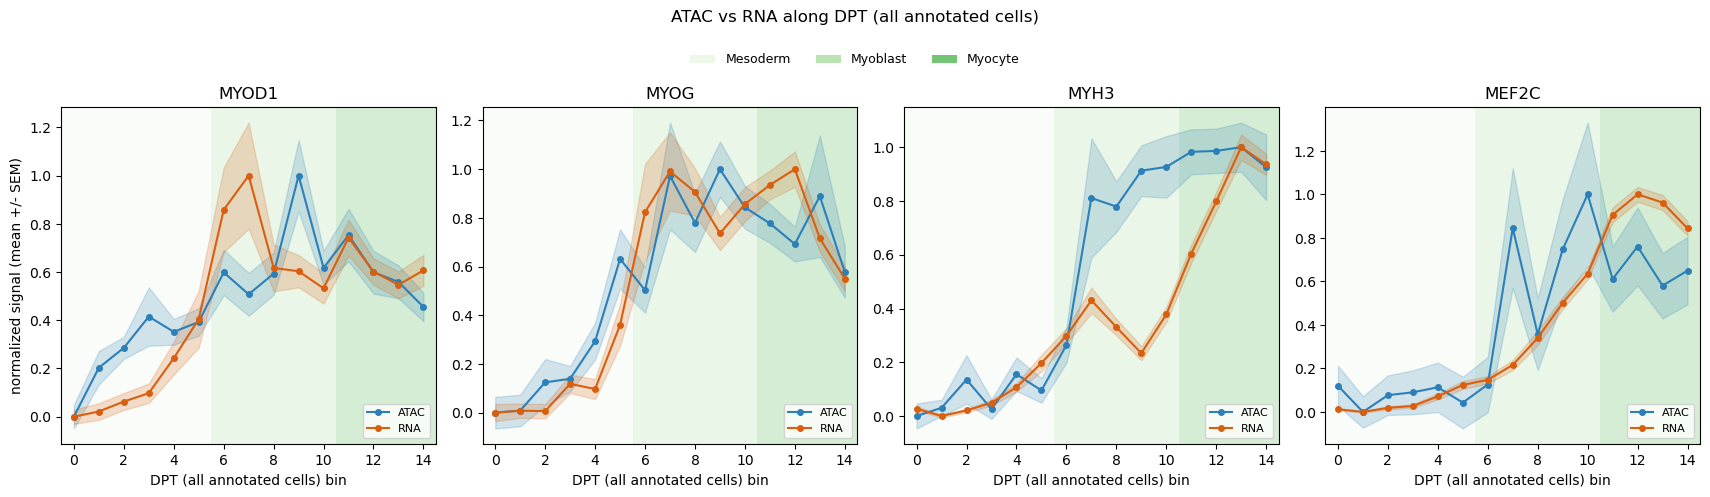

In [248]:
print("DPT mean pseudotime per state:", per_state(adata, "dpt_pseudotime").round(3).to_dict())
df_dpt = atac_precede_grid(pt["dpt_pseudotime"], "DPT (all annotated cells)", "atac_precede_rna_dpt.png")

## 8. CytoTRACE cross-check (velocity-free)
A third, velocity-free ordering. In myogenesis CytoTRACE's 'more genes = more potent' assumption is inverted
(terminal myocytes express a large structural program), so it anti-correlates with DPT here and is reported
as checked-but-inapplicable, not a confirmation.

CytoTRACE per state: {'Mesoderm': 0.9279999732971191, 'Myoblast': 0.9160000085830688, 'Myocyte': 0.8629999756813049}
Spearman CytoTRACE vs DPT   = -0.39
Spearman latent_time vs DPT = 0.16  (velocity, for reference)
[CytoTRACE (all annotated cells)] cells=8055 bins=15 (~537 cells/bin)
state mean bin / mean pseudotime: {'Mesoderm': (8.4, 0.928), 'Myoblast': (7.5, 0.916), 'Myocyte': (4.6, 0.863)}
gene   xcorr_lag(cells)  xcorr_lag(bins)   (+ = ATAC precedes)
  MYOD1           -73            -0.14
  MYOG          -1287            -2.40
  MYH3           -633            -1.18
  MEF2C         -1500            -2.79


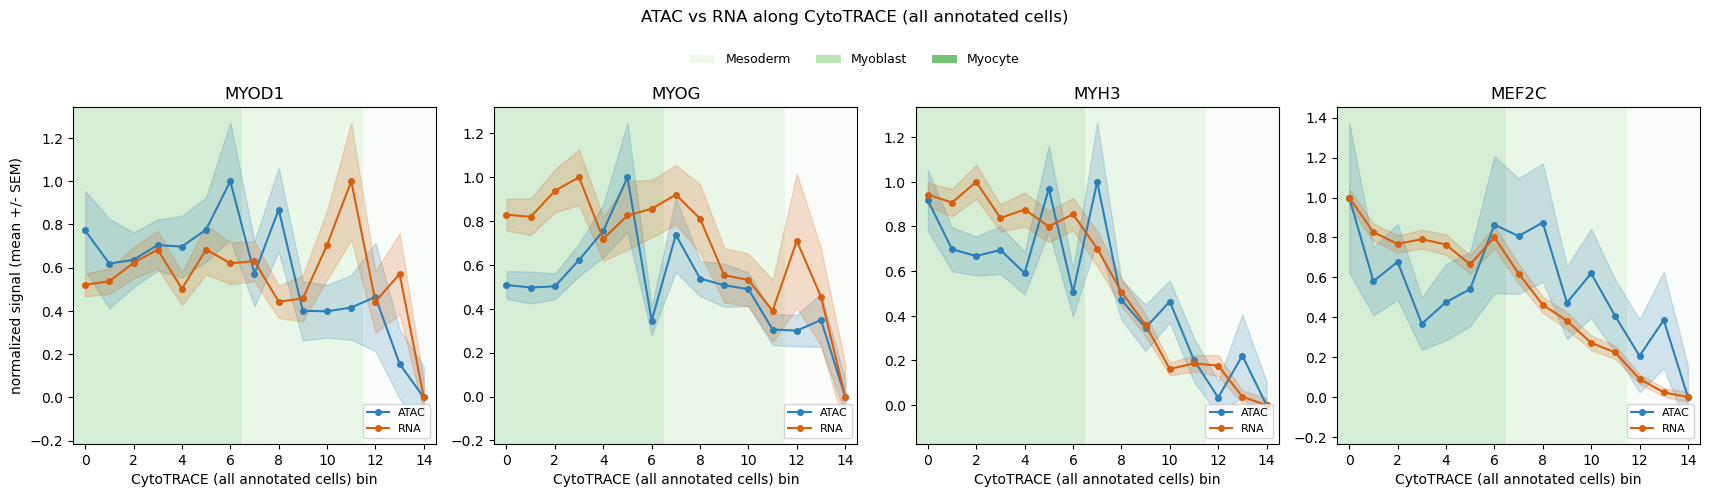

In [249]:
# CytoTRACE-like ordering (velocity-free) -> repeat the ATAC-vs-RNA grid on a third ordering (ALL cells)
if "n_genes_all" not in adata.obs:
    adata.obs["n_genes_all"] = np.asarray((adata.layers.get("spliced", adata.X) > 0).sum(1)).ravel()
def cytotrace_like(ad, n_top=200, n_smooth=3):
    Xl = ad.X.toarray() if sp.issparse(ad.X) else np.asarray(ad.X)
    ng = rankdata(ad.obs["n_genes_all"].values.astype(float)); ng = (ng - ng.mean()) / (ng.std() + 1e-9)
    Xr = np.apply_along_axis(rankdata, 0, Xl); Xr = (Xr - Xr.mean(0)) / (Xr.std(0) + 1e-9)
    corr = (Xr.T @ ng) / len(ng); top = np.argsort(corr)[-n_top:]; gcs = Xl[:, top].mean(1)
    if "connectivities" in ad.obsp:
        C = ad.obsp["connectivities"]; P = C.multiply(1.0 / (np.asarray(C.sum(1)).ravel() + 1e-9))
        for _ in range(n_smooth): gcs = np.asarray(P @ gcs).ravel()
    return (gcs - gcs.min()) / (gcs.max() - gcs.min() + 1e-9)
adata.obs["cytotrace_time"] = 1 - cytotrace_like(adata)               # early -> late (all annotated cells)
print("CytoTRACE per state:", per_state(adata, "cytotrace_time").round(3).to_dict())
print("Spearman CytoTRACE vs DPT   =", round(spearmanr(adata.obs['cytotrace_time'], adata.obs['dpt_pseudotime']).correlation, 2))
print("Spearman latent_time vs DPT =", round(rho, 2), " (velocity, for reference)")
df_cyto = atac_precede_grid(adata.obs["cytotrace_time"], "CytoTRACE (all annotated cells)", "atac_precede_rna_cytotrace.png")

## Interpretation
- **Labels (Sec 1b):** the canonical-marker diagonal validates the Mesoderm/Myoblast/Myocyte annotation.
- **Velocity (Sec 4-6):** the scVelo latent-time ordering is unreliable on this tumor (non-monotonic across
  states, low correlation with DPT), consistent with documented RNA-velocity failure when its constant-rate
  kinetic assumptions are violated (Bergen et al. 2021, Mol Syst Biol). Shown as the attempt, not the result.
- **CytoTRACE (Sec 7):** anti-correlates with DPT here (negative Spearman) - its 'transcriptional diversity =
  potency' assumption is inverted in myogenesis, where terminal myocytes switch on a large structural program
  and therefore express MORE genes (gene-count non-monotonicity noted by SCTC 2024 / CytoTRACE 2). A
  checked-but-inapplicable ordering, not a confirmation.
- **ATAC vs RNA along DPT (Sec 7, primary):** DPT cleanly recapitulates the trajectory, so it is the ordering
  we trust. The lag is the whole-curve cross-correlation (reported in cells and in bins), which is more robust
  than a single half-max crossing. Under fair per-capita normalization (library-normalized RNA, depth-
  normalized ATAC), accessibility and expression rise essentially together at the master regulators
  (MYOD1/MYOG, lag ~0), with at most a small, metric-sensitive lead at the terminal loci (MEF2C's ATAC is too
  sparse to call). There is no robust ATAC-precedes-RNA signal at these marker genes in this dataset; report
  honestly and frame any lead as chromatin priming *consistent with* preceding transcription (pseudotime !=
  real time).